In [2]:
# %load_ext autoreload
# %autoreload 2
%cd ~/code/entityrepresentations/

/home/morand/code/entityrepresentations


# Imports

In [3]:
import pathlib, sys, os, json, time
from importlib import reload
import numpy as np
import pandas as pd
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import tikzplotlib      # need matplotlib<3.6
import IPython
from IPython.display import HTML, display
from processResults import *
import LabelExtractor

# load tokenizer from model
import transformer_lens.loading_from_pretrained as loading
from transformers import AutoTokenizer

reload(sys.modules['processResults'])
reload(sys.modules['LabelExtractor'])

Using the latest cached version of the module from /home/morand/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--chrf/d244bab9383988714085a8dacc4871986d9f025398581c33d6b2ee22836b4069 (last modified on Thu Jun 27 14:17:21 2024) since it couldn't be found locally at evaluate-metric--chrf, or remotely on the Hugging Face Hub.
Using the latest cached version of the module from /home/morand/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--chrf/d244bab9383988714085a8dacc4871986d9f025398581c33d6b2ee22836b4069 (last modified on Thu Jun 27 14:17:21 2024) since it couldn't be found locally at evaluate-metric--chrf, or remotely on the Hugging Face Hub.


<module 'LabelExtractor' from '/home/morand/code/entityrepresentations/LabelExtractor.py'>

## Model sizes and colors

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# Define model sizes
model_sizes = {
    "gpt2-small": 117,
    "gpt2-medium": 302,
    "gpt2-large": 708,
    "gpt2-xl": 1558,
    "phi-1_5": 1500,
    "phi-2": 2600,
    "phi-3": 3800,
    "mistral-7B": 7000,
    "EleutherAI/pythia-160m": 160,
    "EleutherAI/pythia-410m": 302,
    "EleutherAI/pythia-1b"  : 805,
    "EleutherAI/pythia-1.4b": 1200,
    "EleutherAI/pythia-2.8b": 2500,
    "EleutherAI/pythia-6.9b": 6400,
    # "EleutherAI/pythia-12b": 11000,
}
# Define model families
families = {
    "gpt2": [model for model in model_sizes.keys() if "gpt2" in model],
    "phi": [model for model in model_sizes.keys() if "phi" in model],
    "mistral": [model for model in model_sizes.keys() if "mistral" in model],
    "pythia": [model for model in model_sizes.keys() if "pythia" in model]
}
color_maps = {
    "gpt2": plt.cm.PuBuGn,
    "phi": plt.cm.Reds,
    "mistral": plt.cm.Blues,
    "pythia": plt.cm.YlGnBu
}

# Assign colors to models
model_colors = {}
for family, models in families.items():
    cmap = color_maps[family]
    for i, model in enumerate(models):
        # Normalize color range to avoid very light colors
        color = cmap(.2 + (.8*i / len(models)))
        model_colors[model] = color


# Load the results

In [38]:
#get home path
xp_path = pathlib.Path.home() / "experiments_JeanZay"
#get all experiments directories
xp_paths= os.listdir(xp_path / "jobs")
print(f"available jobs: {xp_paths}")

xp = 'labelextractor.learnlabelextractor'
#choose one experiment
jobs_path = xp_path / "jobs" / xp
#get jobs
results = loadResults(jobs_path)
print(results.columns)
#remove jobs with no Eval 
print(f"number of jobs: {len(results)}")
results = results[results["Eval"].notna()]
print(f"number of jobs with eval: {len(results)}")
#print all models
models = results["model_name"].unique()
print(f"available models: {models}")

#extract hash from job name and add in a column
results["hash"] = results["path"].apply(lambda x: x.parts[-1])
results.head()

available jobs: ['labelextractor.learnlabelextractor', 'labelextractor.evallabelextractor', 'labelextractor.learnlinearfilter']


100%|██████████████████████████████████████████████████████████████████████████| 2032/2032 [00:08<00:00, 249.46it/s]


Index(['path', 'model_name', 'layer', 'max_ent_length', 'epochs', 'lr',
       'batch_size', 'with_context', 'dataset_name', 'extraction_method',
       'history', 'Eval', 'date', 'inference', 'logs_per_epoch', 'max_length',
       'run', 'version'],
      dtype='object')
number of jobs: 2032
number of jobs with eval: 1990
available models: ['gpt2-small' 'gpt2-large' 'gpt2-medium' 'phi-2' 'mistral-7B' 'gpt2-xl'
 'phi-1_5' 'EleutherAI/pythia-12b' 'EleutherAI/pythia-1.4b'
 'EleutherAI/pythia-2.8b' 'EleutherAI/pythia-410m' 'EleutherAI/pythia-1b'
 'EleutherAI/pythia-160m' 'EleutherAI/pythia-6.9b' 'phi-3']


,path,model_name,layer,max_ent_length,epochs,lr,batch_size,with_context,dataset_name,extraction_method,history,Eval,date,inference,logs_per_epoch,max_length,run,version,hash
0,/home/morand/experiments_JeanZay/jobs/labelext...,gpt2-small,11,20,10,0.01,32,False,WebNLG,after_context,"[{'loss': 2.415166044915755, 'test accuracy': ...","{'Partial Match': 0.21923882251508806, 'Exact ...",1.722885e+09,/home/morand/experiments_JeanZay/jobs/labelext...,NaN,NaN,NaN,NaN,1e2c29f6e98fb5ed9d711de34fe11165652ba427b80da6...
1,/home/morand/experiments_JeanZay/jobs/labelext...,gpt2-small,3,20,10,0.01,32,False,WebNLG,after_context,"[{'loss': 3.1949900441517043, 'test accuracy':...","{'Partial Match': 0.15886122750801085, 'Exact ...",1.722885e+09,/home/morand/experiments_JeanZay/jobs/labelext...,NaN,NaN,NaN,NaN,20861ccc2a0bf5f496780417f1594f2d5fae02eac1e97b...
2,/home/morand/experiments_JeanZay/jobs/labelext...,gpt2-small,8,20,10,0.01,32,False,WebNLG,after_context,"[{'loss': 3.216486542830317, 'test accuracy': ...","{'Partial Match': 0.16061091267397462, 'Exact ...",1.722885e+09,/home/morand/experiments_JeanZay/jobs/labelext...,NaN,NaN,NaN,NaN,42e57f62ac53e3a932fc7ab751e88917e98dfbc8fbe327...
3,/home/morand/experiments_JeanZay/jobs/labelext...,gpt2-small,6,20,10,0.01,32,False,WebNLG,after_context,"[{'loss': 3.5189963487658913, 'test accuracy':...","{'Partial Match': 0.13696268013302132, 'Exact ...",1.722885e+09,/home/morand/experiments_JeanZay/jobs/labelext...,NaN,NaN,NaN,NaN,6b032af8521e7d0dd98c60153b74dc1888850dcc96d73f...
4,/home/morand/experiments_JeanZay/jobs/labelext...,gpt2-small,0,20,10,0.01,32,False,WebNLG,after_context,"[{'loss': 2.736201476393722, 'test accuracy': ...","{'Partial Match': 0.16125447586121744, 'Exact ...",1.722885e+09,/home/morand/experiments_JeanZay/jobs/labelext...,NaN,NaN,NaN,NaN,703f5a156bfe5d953c1ebace771da0d39ce3a1e672604b...


In [57]:
xp_lin = 'labelextractor.learnlinearfilter'

#get jobs
results_linear = loadResults(xp_path / "jobs" / xp_lin)
print(f"{len(results_linear)} jobs loaded")
#remove jobs with no Eval
results_linear = results_linear[results_linear["Eval"].notna()]
results_linear["hash"] = results_linear["path"].apply(lambda x: x.parts[-1])
print(f"{len(results_linear)} jobs with eval")
# results_linear.head()

100%|█████████████████████████████████████████████████████████████████████████████| 830/830 [00:46<00:00, 18.02it/s]

830 jobs loaded
726 jobs with eval


In [7]:
# scan folder for failed jobs
failed_jobs = []
jobs = os.listdir(jobs_path)
xp = xp_paths[0].split(".")[-1]
for job in jobs:
    if os.path.exists(jobs_path / job / (xp + ".failed")):
        failed_jobs.append(job)
print(f"failed jobs {len(failed_jobs)}: {failed_jobs}")

failed jobs 0: []


In [8]:
print(" ",results['Eval'].isna().sum())
results.describe()

  0


,layer,max_ent_length,epochs,lr,batch_size,date,logs_per_epoch,max_length,run
count,1968.000000,1968.0,1968.000000,1968.000000,1968.000000,1.968000e+03,1912.000000,1765.0,561.000000
mean,13.809451,20.0,10.505081,0.035064,41.363821,1.725214e+09,3.569038,200.0,1.705882
std,9.647513,0.0,2.527123,0.012965,13.686361,1.473860e+06,0.831386,0.0,1.319138
min,-1.000000,20.0,1.000000,0.001000,30.000000,1.722885e+09,1.000000,200.0,0.000000
25%,6.000000,20.0,10.000000,0.020000,30.000000,1.724709e+09,4.000000,200.0,1.000000
50%,13.000000,20.0,10.000000,0.040000,32.000000,1.724970e+09,4.000000,200.0,2.000000
75%,21.000000,20.0,10.000000,0.050000,50.000000,1.726856e+09,4.000000,200.0,3.000000
max,47.000000,20.0,30.000000,0.050000,80.000000,1.727333e+09,4.000000,200.0,4.000000


# Raw Performance by Layer

## For One Model


### Choose one model

In [75]:
# model_name = next(iter(results.keys()))
model_name = "gpt2-small"
model_name = "gpt2-medium"
model_name = "gpt2-large"
model_name = "gpt2-xl"
model_name = "mistral-7B"
model_name = "phi-1_5"
model_name = "EleutherAI/pythia-1.4b"
model_name = "EleutherAI/pythia-160m"
model_name = "EleutherAI/pythia-6.9b"
model_name = "EleutherAI/pythia-2.8b"
model_name = "phi-3"
model_name = "EleutherAI/pythia-1b"
model_name = "EleutherAI/pythia-410m"
model_name = "EleutherAI/pythia-12b"
model_name = "phi-2"

with_context = False
with_context = True

dataset_name = "TACRED"
dataset_name = "WebNLG"
dataset_name = "CoNLL2003"

method = "after_context"
method = "average"
method = "in_context"
method = "random_sample"

filtered_results = results[(results["model_name"] == model_name) 
                           & (results["dataset_name"] == dataset_name) 
                        #    & (results["lr"] == 0.05) 
                           & (results["extraction_method"] == method)
                           & (results["with_context"] == with_context)]
print(f"filtered results: {len(filtered_results)}")

filtered_results_linear = results_linear[   (results_linear["model_name"] == model_name)
                                          & (results_linear["dataset_name"] == dataset_name)
                                          & (results_linear["with_context"] == with_context)
                                          & (results_linear["extraction_method"] == method)
                                          ]
print(f"filtered results linear: {len(filtered_results_linear)}")
#don't show 'path' column, show full 'hash column'

filtered results: 11
filtered results linear: 0


#### Show all selected results

In [10]:
method = "in_context"
method = "average"

html = filtered_results[
    (filtered_results['layer'] == 23) &
    (filtered_results['extraction_method'] == method)
    ].drop(columns=["path",
                                      "history","max_length","logs_per_epoch","version","inference",
                                      "Eval"
                                      ]
                      ).sort_values(by="layer", ascending=False).to_html()

display(HTML(html))

,model_name,layer,max_ent_length,epochs,lr,batch_size,with_context,dataset_name,extraction_method,date,run,hash
1349,phi-2,23,20,10,0.05,30,True,CoNLL2003,average,1.725283e+09,NaN,0184b2ddd783a5468ec87e1001a88429f97fdb10a9f70ef0411d8060689933e5
1879,phi-2,23,20,10,0.04,30,True,CoNLL2003,average,1.727321e+09,0.0,033f7ba7122d79160fc97f3349e88a122901dd3557ab4435d49325390eef6ed8
1972,phi-2,23,20,10,0.04,30,True,CoNLL2003,average,1.727321e+09,3.0,a22243f82b96f83152bf3626bedf61214c73344297548569bd381f4c1100a789
1978,phi-2,23,20,10,0.04,30,True,CoNLL2003,average,1.727321e+09,2.0,af83df7989c49235142327e40576b95d64fdf7f0df2b16bb4ed5e26ff7d2231b
1988,phi-2,23,20,10,0.04,30,True,CoNLL2003,average,1.727321e+09,1.0,c62acb5eb993c9d78f43fdf8199e9ffa96e0854e44ff61110a1e7075afd09402


#### Show all selected Linear results

In [11]:
html = filtered_results_linear[
    (filtered_results_linear['layer'] == 23) 
    # & (filtered_results_linear['extraction_method'] == "in_context")
    ].drop(columns=["job_path","path","history","max_length","logs_per_epoch","version","inference",
                    "Eval", "TaskVec_path"
                    ]
                      ).sort_values(by="layer", ascending=False).to_html()

display(HTML(html))

,model_name,dataset_name,layer,batch_size,epochs,lr,with_context,extraction_method,max_ent_length,date,run,hash
330,phi-2,CoNLL2003,23,30,10,0.01,True,in_context,20,1.727197e+09,0.0,032c35c158b3f040d2be39ba18bdf348108c898d0f0dbaf79c35f33a1783988c
347,phi-2,CoNLL2003,23,30,10,0.01,True,in_context,20,1.727218e+09,0.0,1599f0d662f1de9082de251f1d9b685a2b9c79b39eee690e3f7a7df575071064
413,phi-2,CoNLL2003,23,30,10,0.01,True,in_context,20,1.727221e+09,0.0,61460b3ee6b1458e3e225b7c7f8a4ae0836f29f1af6945d2697d95cb8a165c05
437,phi-2,CoNLL2003,23,30,10,0.01,True,in_context,20,1.727219e+09,0.0,7d29fc3464aa5a0b7b9d9e7f4943103fc815945d0e6fc4545e656792cbdaa558
458,phi-2,CoNLL2003,23,30,10,0.01,True,in_context,20,1.727216e+09,0.0,9f205e08af5e869e5165da1a7abecb4377990bc823647557468638b5a536f3b7
478,phi-2,CoNLL2003,23,30,10,0.01,True,in_context,20,1.727220e+09,0.0,b5be7d8321604dbc2e0a5dd4d1c78b7c04a58bac156319a9074047c6222481ff
723,phi-2,CoNLL2003,23,30,10,0.01,True,average,20,1.727304e+09,0.0,a1e494bb277a20bb67dd2746fac906e4734c03f9a7ddcecb1a3b7f65d0601cbf


In [12]:
path = filtered_results_linear.iloc[0]['path']
files = [file for file in os.listdir(path) if file.endswith(".pth")]
print(f"files: {files}")

files: ['LinearFilter_phi-2_l23_e10.0Context.pth']


### Display Train Curves

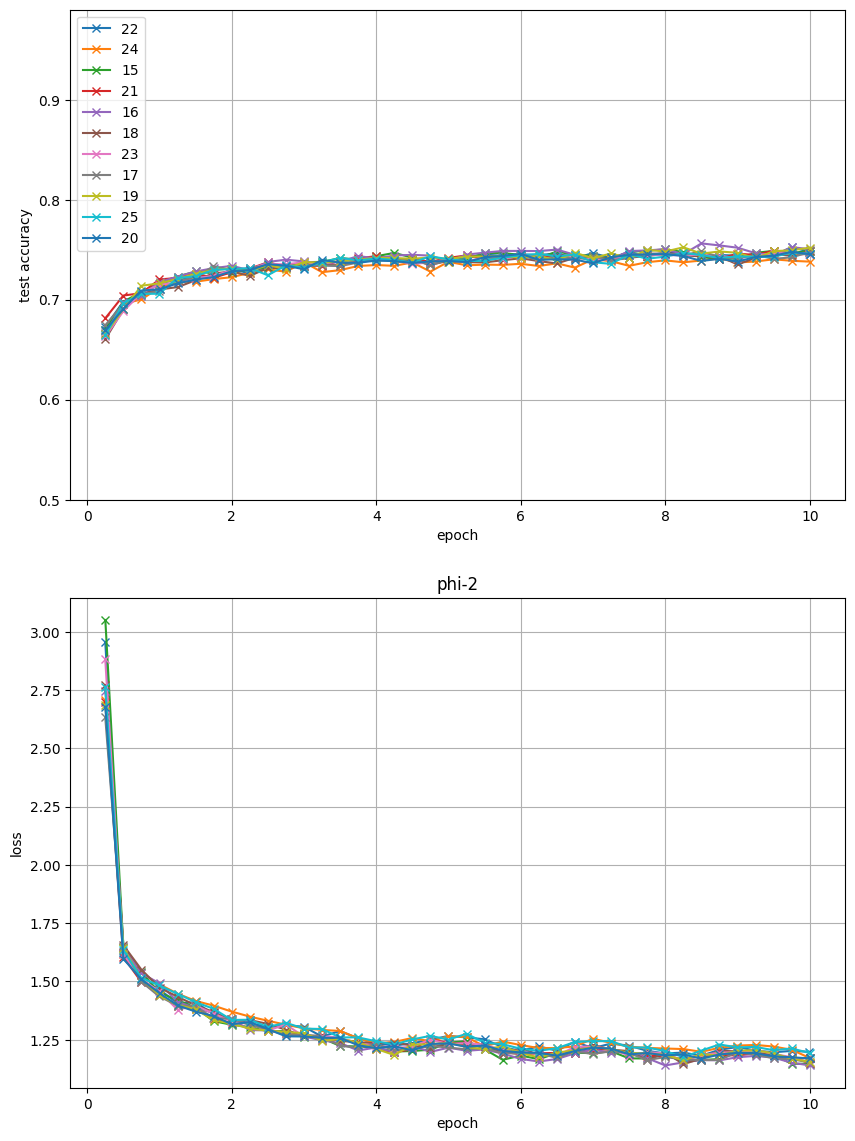

In [76]:

#two subfigs 
fig, axes = plt.subplots(2, 1, figsize=(10, 14))
ax1, ax2 = axes
for ind, data in filtered_results.iterrows():
    # if layer == 10:
    hist = data["history"]
    epochs = []
    for i, log in enumerate(hist):
        if "test accuracy" not in log:
            hist[i]["test accuracy"] = None
        epochs.append(log.get("epoch", i))
    #plot train accuracy on othe axis
    ax1.plot(epochs, [log["test accuracy"] for log in hist], 'x-', label=data["layer"]) 
    ax2.plot(epochs, [log["loss"] for log in hist ], 'x-', label=data["layer"])
ax1.set_xlabel("epoch")
ax1.set_ylabel("test accuracy")
ax2.set_xlabel("epoch")
ax2.set_ylabel("loss")
ax1.set_ylim(0.5, .99)
ax1.grid()
ax2.grid()
ax1.legend()
plt.title(model_name)
plt.show()

In [78]:
for ind, data in filtered_results.iterrows():
    hist = data["history"]
    epochs = []
    if data['layer'] == 22:
        print(data['history'])

[{'epoch': 0.2489208633093525, 'loss': 2.9566805057388414, 'test accuracy': 0.6725929014144405, 'lr': 0.04}, {'epoch': 0.497841726618705, 'loss': 1.621398499029146, 'test accuracy': 0.6980572237122443, 'lr': 0.04}, {'epoch': 0.7467625899280576, 'loss': 1.5038902440517068, 'test accuracy': 0.7052053203505855, 'lr': 0.04}, {'epoch': 0.99568345323741, 'loss': 1.4662565704729917, 'test accuracy': 0.7159213510251814, 'lr': 0.04}, {'epoch': 1.2489208633093525, 'loss': 1.405824844442683, 'test accuracy': 0.7206623102388074, 'lr': 0.04}, {'epoch': 1.497841726618705, 'loss': 1.4111346855438014, 'test accuracy': 0.723020568970711, 'lr': 0.04}, {'epoch': 1.7467625899280574, 'loss': 1.3591250186343844, 'test accuracy': 0.7219086452837913, 'lr': 0.04}, {'epoch': 1.99568345323741, 'loss': 1.33935442416788, 'test accuracy': 0.7306818596778377, 'lr': 0.04}, {'epoch': 2.2489208633093525, 'loss': 1.3196532287185998, 'test accuracy': 0.7263441239633868, 'lr': 0.04}, {'epoch': 2.497841726618705, 'loss': 1

### Inspect best runs 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


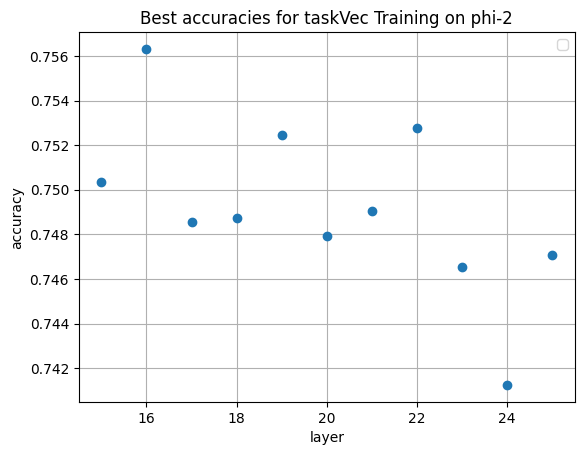

In [79]:
layers = []
accs = []
for ind, data in filtered_results.iterrows():
    layers.append(data["layer"])
    
    accs.append(
        np.max( [log["test accuracy"] for log in data["history"]])
        # [log["test accuracy"] for log in results[model_name][layer]][-1]
        ) 
plt.plot(layers, accs, 'o')
plt.legend()
plt.title(f"Best accuracies for taskVec Training on {model_name.split('/')[-1]}")
plt.xlabel("layer")
plt.ylabel("accuracy")
plt.grid()
plt.show()

In [67]:
def plot_all_interactive(
        metric: str,
        filtered_results: pd.DataFrame,
        ):
    layers = []
    accs = []
    hover_texts = []
    y = []
    for ind, data in filtered_results.iterrows():
        layers.append(data["layer"])
        try:
            acc = max([log["test accuracy"] for log in data["history"]])
        except:
            acc = np.nan
        m = data["Eval"][metric]
        y.append(m)
        accs.append(acc)
        t = data["date"]
        date_hr = time.strftime('%b %d %Hh%M', time.localtime(t))
        hover_text = f"run {data['run']} | Layer: {data['layer']} | acc: {acc:.3f}<br>epochs: {data['epochs']}, LR: {data['lr']}, b_size: {data['batch_size']}<br>{metric}: {data['Eval'][metric]:.2f}<br>{data['extraction_method']} | {date_hr}"  # Adjust as needed
        hover_texts.append(hover_text)

    # Create a scatter plot
    fig = go.Figure(data=go.Scatter(
        x=layers,
        # y=accs,
        y=y,
        mode='markers',
        marker=dict(size=10),
        text=hover_texts,  # Hover text
        hoverinfo='text'
            ),
        )

    # Add titles and labels
    fig.update_layout(
        title=f"{model_name.split('/')[-1]} on {dataset_name} with{'' if with_context else 'out'} context: Inferred Labels {metric}",
        xaxis_title="Layer",
        yaxis_title=metric,
        legend_title="Legend",
        hovermode="closest",
        width=1500,
        height=800,
    )
    fig.show()


metric = "Partial Match"
metric = "Chr-F"
metric = "Exact Match"


plot_all_interactive(metric, filtered_results)

In [17]:
plot_all_interactive(metric, filtered_results_linear)

## Aggregated Plots

### All Perfs with after_context

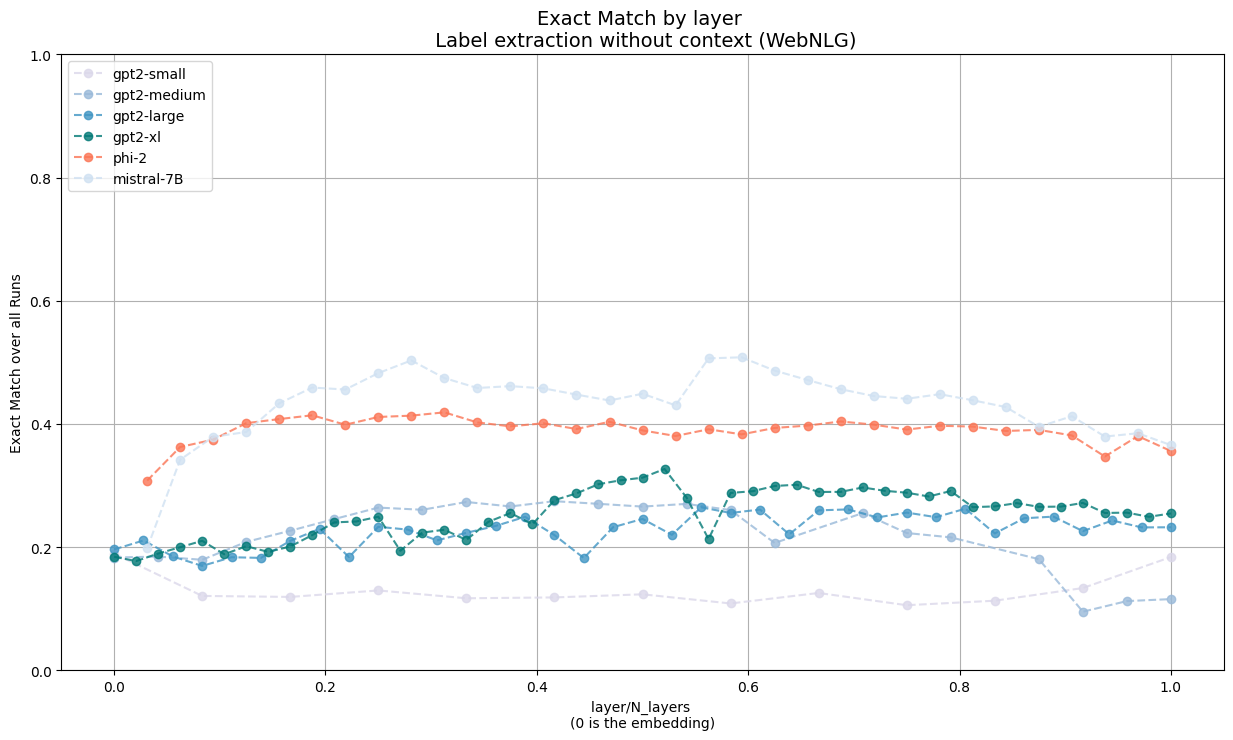

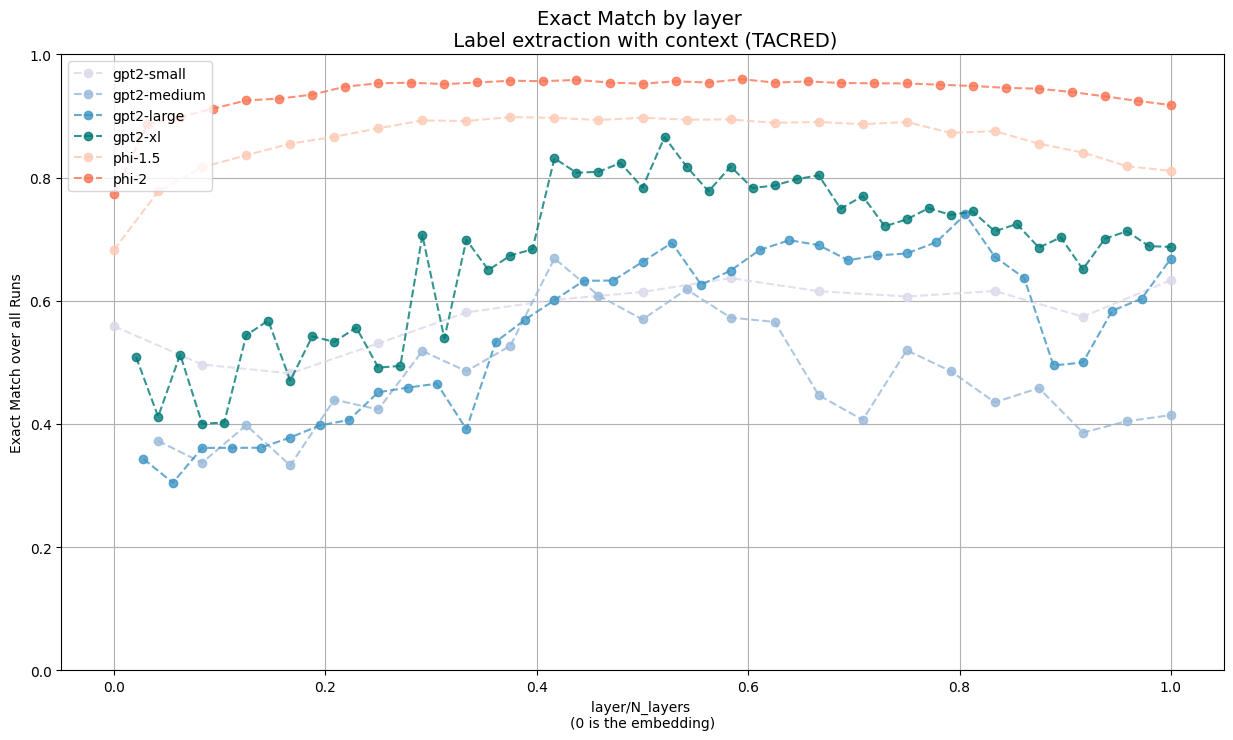

In [18]:
metric = "Best accuracy"
metric = "Partial Match"
metric = "Chr-F"
metric = "Exact Match"
method = "after_context"
min_y = .0

def plot_aggregated(results,
                    metric, 
                    dataset=None, 
                    with_context=True,
                    method="in_context",
                    normalize_layers=False, 
                    min_y=0.0, 
                    max_y=1.0):
    plt.figure(figsize=(15, 8))
    #get Best accuracy for all models
    if dataset is None:
        datasets, counts = np.unique( results[(results["with_context"] == with_context) & (results["Eval"].notna())]["dataset_name"], return_counts=True)
        # keep only dataset with most counts
        dataset_name = datasets[np.argmax(counts)]
    else:
        dataset_name = dataset
    
    for model in model_sizes.keys():
        y = {}
        filtered_results = results[(results["model_name"] == model) & 
                                (results["with_context"] == with_context) & 
                                (results["dataset_name"] == dataset_name) & 
                                (results["extraction_method"] == method) & 
                                (results["Eval"].notna())]
        if len(filtered_results) == 0:
            continue
        for ind, data in filtered_results.iterrows():
            if metric == "Best accuracy":
                acc = max( [log["test accuracy"] for log in data["history"]])
                #if several runs, keep the best
                y[data["layer"]] = max(y.get(data["layer"], 0), acc)
            else:
                y[data["layer"]] = max(y.get(data["layer"], 0), data['Eval'][metric])
        
        #get sorted lists
        layers = list(y.keys())
        layers.sort()
        y = [y[k] for k in layers]
        x =  [l + 1 for l in layers]
        
        if normalize_layers:
            lay_max = x[-1]
            x = [l / lay_max for l in x]
        plt.plot(x, y, 'o--',
                        label=model.split("/")[-1].replace("_","."),
                        color=model_colors[model],
                        alpha=0.8)
    plt.legend(loc = "upper left")
    # plt.xticks(list(plt.xticks()[0]), 
    #             labels=[('embed' if l== 0 else str(int(l))) 
    #                     for l in plt.xticks()[0]],
    #             rotation=45)
    plt.ylim(min_y, max_y)
    # plt.xlim(-1)
    plt.title(f"{metric} by layer \n Label extraction {'with' if with_context else 'without'} context ({dataset_name})", fontsize=14)
    plt.xlabel(f"layer{'/N_layers' if normalize_layers else ''} \n(0 is the embedding)")
    plt.ylabel(f"{metric} over all Runs")
    plt.grid()

plot_aggregated(results, metric, "WebNLG", with_context = False, method=method, normalize_layers=True)
plt.show()
plot_aggregated(results, metric, "TACRED" , with_context = True, method=method, normalize_layers=True)
plt.show()

### All Perfs on CoNLL2003

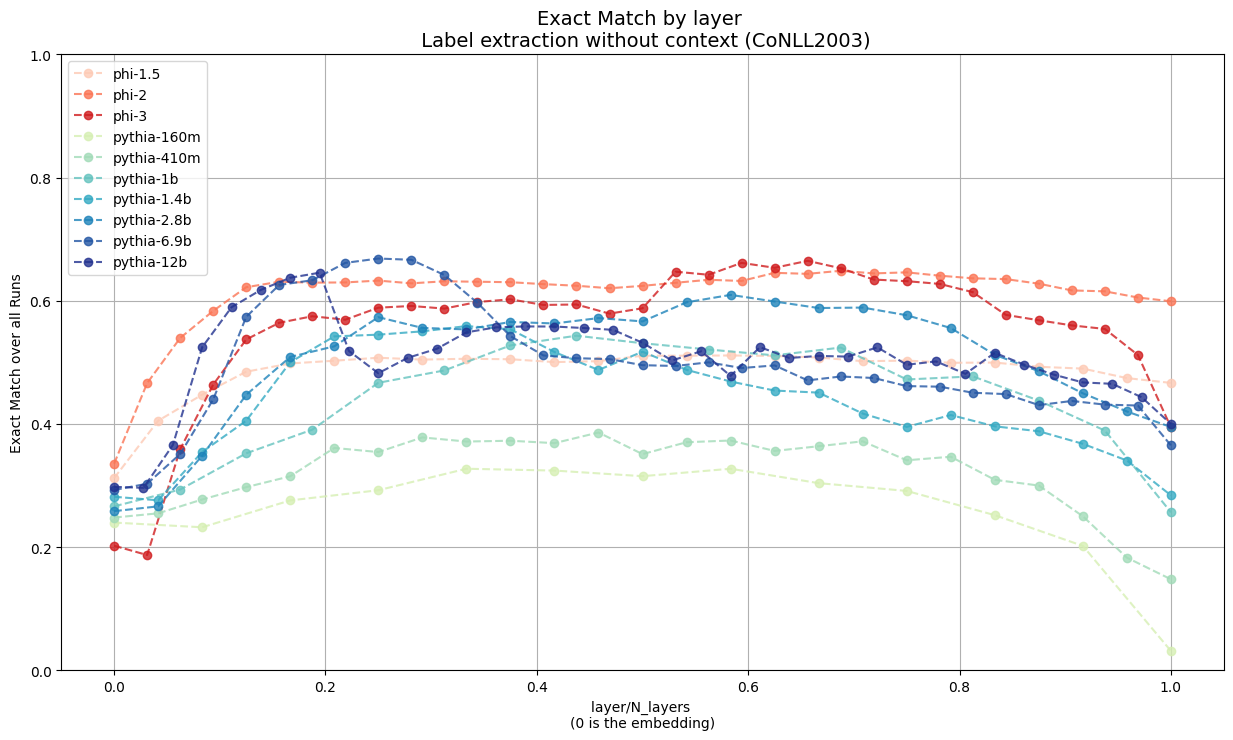

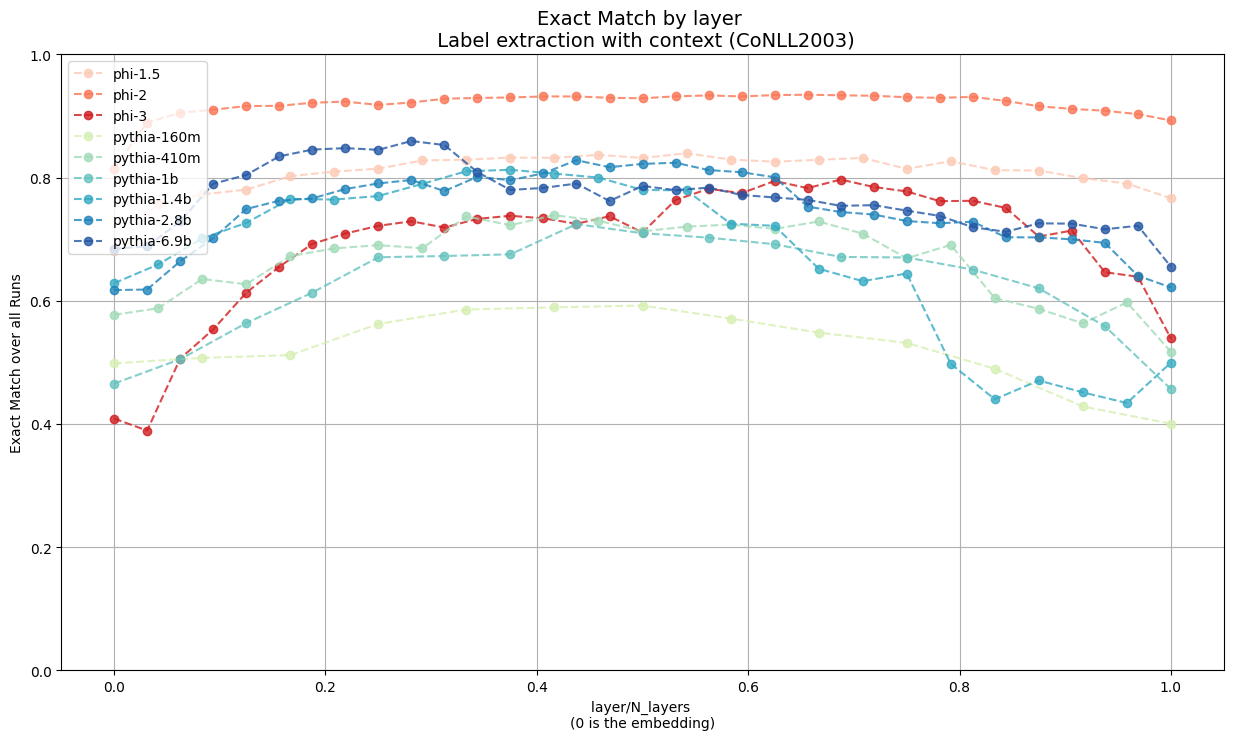

In [19]:
metric = "Partial Match"
metric = "Best accuracy"
metric = "Chr-F"
metric = "Exact Match"

dataset = "WebNLG"
dataset = "TACRED"
dataset = "CoNLL2003"

method = "in_context"

plot_aggregated(results, metric, dataset, with_context = False, 
                normalize_layers=True,
                method=method,
                max_y= 100 if metric == "Chr-F" else 1)
tikzplotlib.save(f"./plots/{dataset}_{metric.replace(' ','')}_no_context.tex")
plt.show()
plot_aggregated(results, metric, dataset, with_context = True,
                normalize_layers=True,
                method=method,
                max_y= 100 if metric == "Chr-F" else 1)
tikzplotlib.save(f"./plots/{dataset}_{metric.replace(' ','')}_with_context.tex")
plt.show()

### Plot perfs according to model size

In [46]:
# define plotter
def plot_best_perfs(dataset_name, with_context, extraction_method, metric):
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    #get best acc for all models
    best_ys = {}
    for model_name in model_sizes.keys():
        filtered_results = results[(results["model_name"] == model_name) 
                                    & (results["with_context"] == with_context) 
                                    & (results["extraction_method"] == extraction_method) 
                                    & (results["dataset_name"] == dataset_name) 
                                    & (results["Eval"].notna())]
        ys = []
        if len(filtered_results) == 0:
            # print(f"no results for {model_name}")
            continue
        for ind, data in filtered_results.iterrows():
            if metric == "Best accuracy":
                ys.append(
                    max( [log["test accuracy"] for log in data["history"]])
                    ) 
            else:
                ys.append(data['Eval'][metric])
        best_ys[model_name] = max(ys)

            ## add dotted line per family
    for family, models in families.items():
        sizes = [model_sizes[model]/1e3 for model in models if model in best_ys]
        ys = [best_ys[model] for model in models if model in best_ys]
        if len(sizes) > 1:
            ax.plot(sizes, ys, '--', color=model_colors[models[-1]] , alpha=0.5)
    #plot best accs as a function of model size
    for model_name, size in model_sizes.items():
        if model_name in best_ys:
            label = model_name.split("/")[-1].replace("_",".")
            ax.plot(size/1000, best_ys[model_name], 'o', color=model_colors[model_name])
            ax.text(size/1000 + .03, best_ys[model_name], label, fontsize=12)
                    
    ax.set_xlabel("Model size (B parameters)")
    ax.set_ylabel(metric)
    # ax.set_xscale('log')   #set log scale 
    ax.grid()
    ax.set_title(f" {metric} for label extraction \n {'with' if with_context else 'without'} context on {dataset_name}")

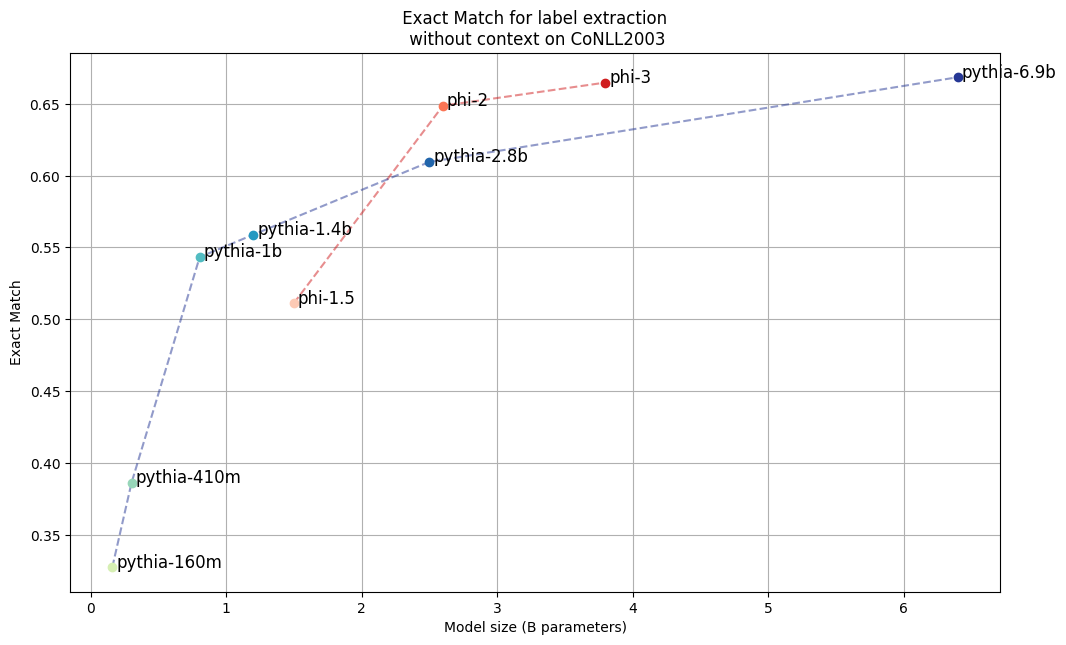

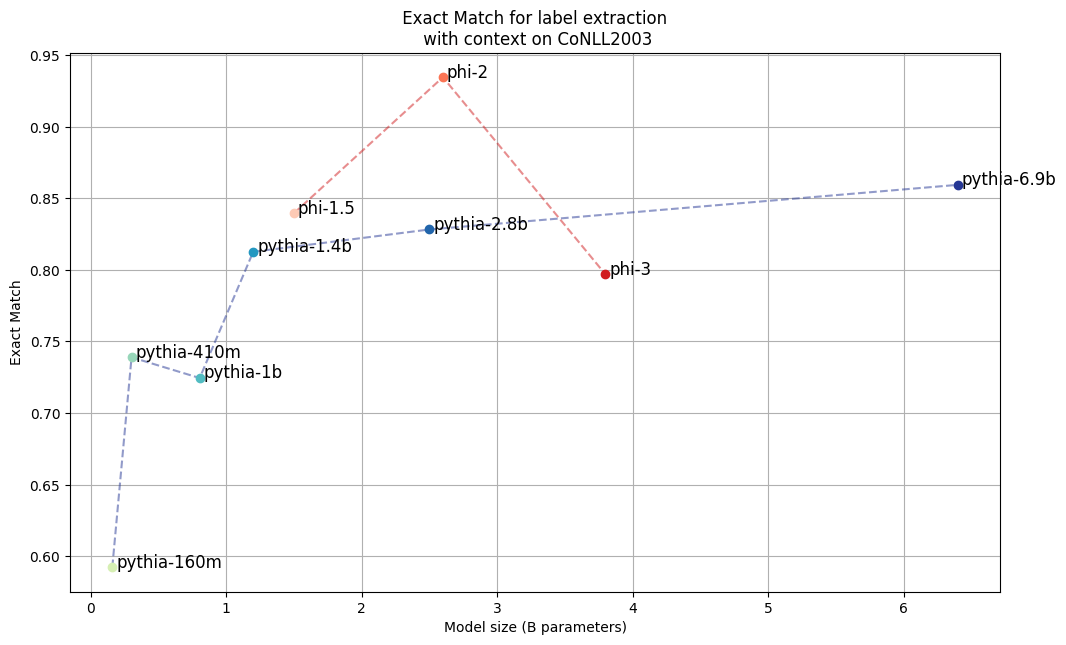

In [47]:
dataset_name = "TACRED"
dataset_name = "WebNLG"
dataset_name = "CoNLL2003"

extraction_method = "after_context"
extraction_method = "in_context"

metric = "Partial Match"
metric = "Best accuracy"
metric = "Chr-F"
metric = "Exact Match"

plot_best_perfs(dataset_name, with_context=False, extraction_method=extraction_method, metric=metric)
tikzplotlib.save(f"./plots/Sizes_{dataset_name}_{metric.replace(' ','')}_no_context.tex")
plt.show()
plot_best_perfs(dataset_name, with_context=True, extraction_method=extraction_method, metric=metric)
tikzplotlib.save(f"./plots/Sizes_{dataset_name}_{metric.replace(' ','')}_with_context.tex")
plt.show()

## Cross method Comparison

#### Raw perf comparison

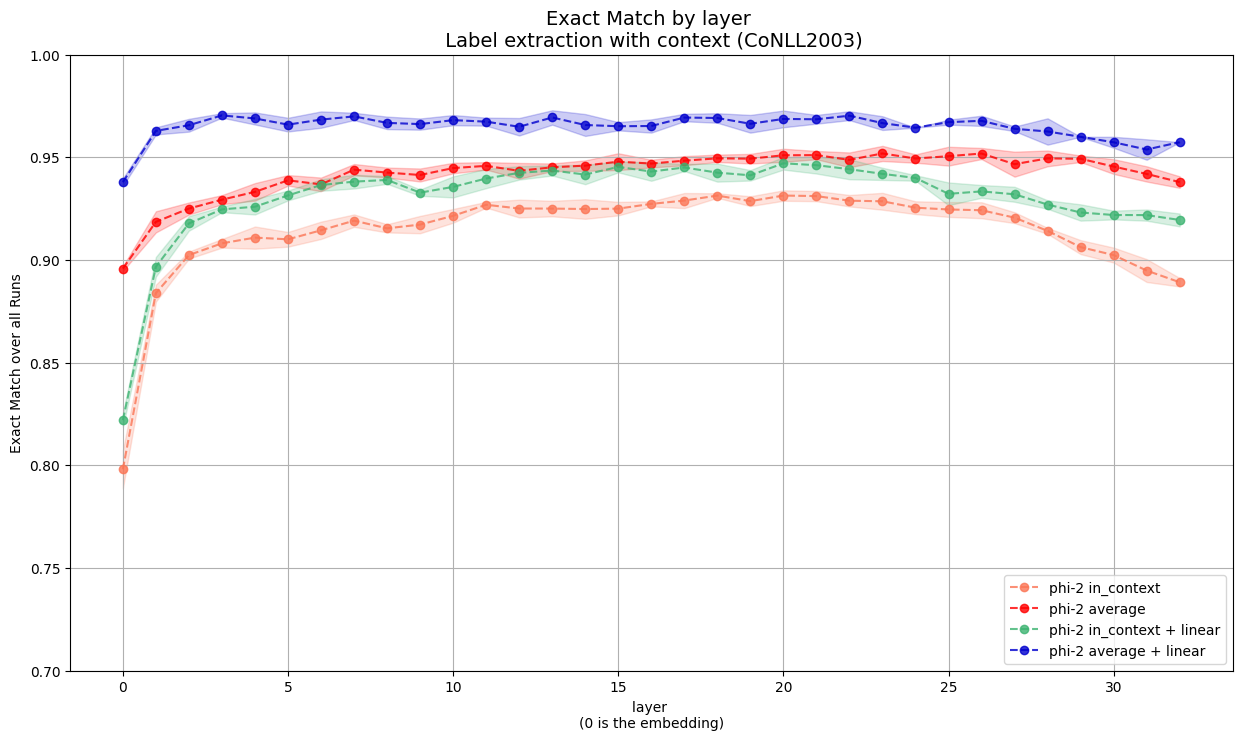

In [22]:
metric = "Best accuracy"
metric = "Partial Match"
metric = "Chr-F"
metric = "Exact Match"
methods = [
    "in_context",
    "average",
]
dataset = "CoNLL2003"
model_name = "phi-2"
with_context = True
normalize_layers = True
normalize_layers = False
min_y = .7
max_y = 1.0 if metric != "Chr-F" else 100

def plot_aggregated_methods(results,
                            model_name,
                            metric,
                            dataset=None,
                            with_context=True,
                            methods=["in_context"],
                            results_linear=None,
                            normalize_layers=True,
                            min_y=0.0,
                            max_y=1.0):
    plt.figure(figsize=(15, 8))
    #get Best accuracy for all models
    if dataset is None:
        datasets, counts = np.unique( results[(results["with_context"] == with_context) & (results["Eval"].notna())]["dataset_name"], return_counts=True)
        # keep only dataset with most counts
        dataset_name = datasets[np.argmax(counts)]
    else:
        dataset_name = dataset

    for results, linear in zip([results, results_linear], [False, True]):
        if results is None:
            continue
        for method in methods:
            y = {}
            filtered_results = results[(results["model_name"] == model_name) & 
                                    (results["with_context"] == with_context) & 
                                    (results["dataset_name"] == dataset_name) & 
                                    (results["extraction_method"] == method) & 
                                    (results["Eval"].notna())]
            if len(filtered_results) == 0:
                continue
            
            for ind, data in filtered_results.iterrows():
                if metric == "Best accuracy":
                    acc = max( [log["test accuracy"] for log in data["history"]])
                    #append to list
                    y[data["layer"]] = y.get(data["layer"], []) + [acc] 
                else:
                    #append to list
                    y[data["layer"]] = y.get(data["layer"], []) + [data['Eval'][metric]] 
            
            #get sorted lists
            layers = list(y.keys())
            layers.sort()
            x =  [l + 1 for l in layers]
            y_all = [y[k] for k in layers]
            y = [np.mean(l) for l in y_all]
            y_err = [np.std(l) for l in y_all]
            
            if normalize_layers:
                lay_max = x[-1]
                x = [l / lay_max for l in x]
            
            if linear :
                if method == "average":
                    color = 'mediumblue'
                else: 
                    color = 'mediumseagreen'
            else:
                if method == "average":
                    color = 'red'
                else :
                    color = model_colors[model_name]
            plt.plot(x, y, 'o--',
                            label=model_name.split("/")[-1].replace("_",".") + f" {method}" + (" + linear" if linear else ""),
                            color=color,
                            alpha=0.8)
            plt.fill_between(x, [y - e for y, e in zip(y, y_err)], [y + e for y, e in zip(y, y_err)], 
                            color=color,
                            alpha=0.2)
                
    plt.legend(loc = "lower right")
    # plt.xticks(list(plt.xticks()[0]), 
    #             labels=[('embed' if l== 0 else str(int(l))) 
    #                     for l in plt.xticks()[0]],
    #             rotation=45)
    plt.ylim(min_y, max_y)
    # plt.xlim(-1)
    plt.title(f"{metric} by layer \n Label extraction {'with' if with_context else 'without'} context ({dataset_name})", fontsize=14)
    plt.xlabel(f"layer{'/N_layers' if normalize_layers else ''} \n(0 is the embedding)")
    plt.ylabel(f"{metric} over all Runs")
    plt.grid()

plot_aggregated_methods(results,
                        model_name, 
                        metric, 
                        dataset=dataset,
                        results_linear=results_linear, 
                        with_context = with_context, 
                        methods=methods, 
                        normalize_layers=normalize_layers, 
                        min_y=min_y, max_y=max_y)
tikzplotlib.save(f"./plots/Baselines_{dataset}_{metric.replace(' ','')}_with_context.tex")
plt.show()

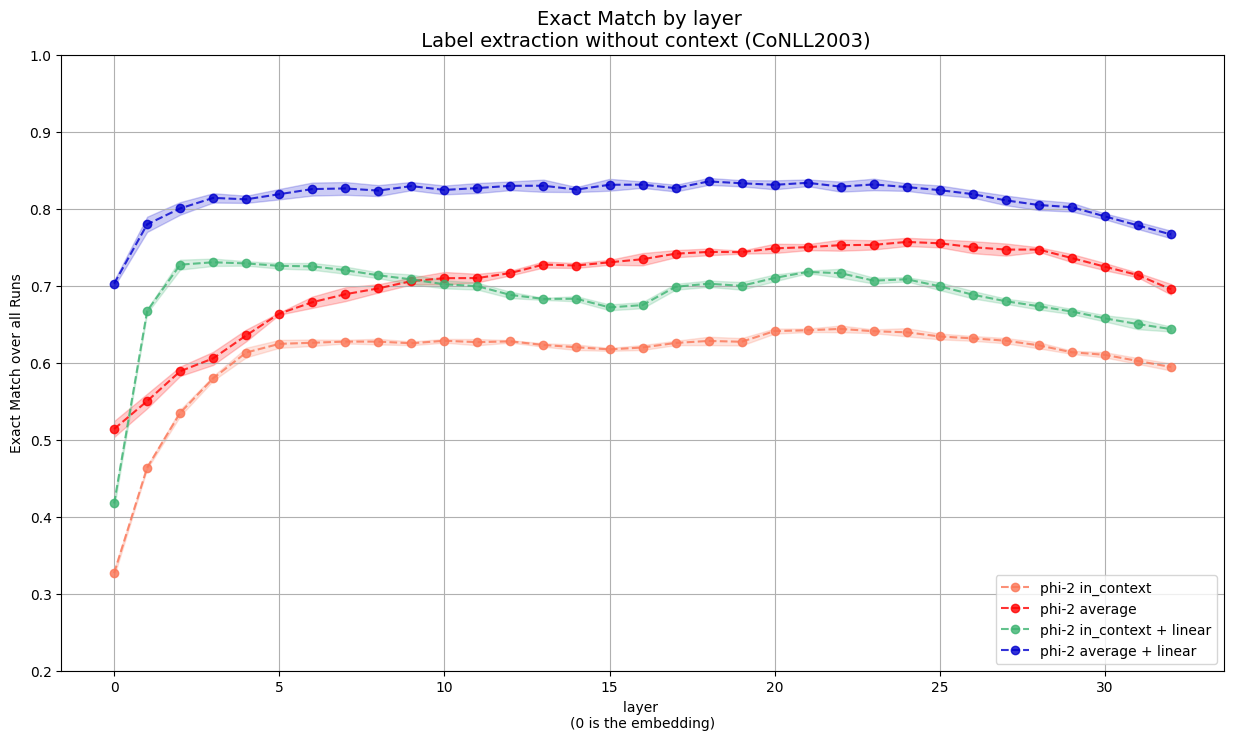

In [23]:
min_y = .2
plot_aggregated_methods(results,
                        model_name, 
                        metric, 
                        dataset=dataset, 
                        results_linear=results_linear, 
                        with_context = False, 
                        methods=methods, 
                        normalize_layers=normalize_layers, 
                        min_y=min_y, max_y=max_y)
tikzplotlib.save(f"./plots/Baselines_{dataset}_{metric.replace(' ','')}_no_context.tex")
plt.show()

### Perf on >1 tokens labels

In [24]:
def filter_results_by_tokens(results, tokenizer, min_tokens=0, max_tokens=100):
    """Filter an inference data according to the numer of tokens for each label"""
    
    #check if results contain tokens and n_tokens columns
    if not "tokens" in results[0].keys():
        for item in results:
            #tokenize the label
            tokens = tokenizer(item['entity'])["input_ids"]
            str_tokens = tokenizer.convert_ids_to_tokens(tokens)
            item["tokens"] = str_tokens
            item["n_tokens"] = len(str_tokens)
    
    return [item for item in results if (item["n_tokens"] >= min_tokens) and (item["n_tokens"] <= max_tokens)]                  

In [25]:

min_tokens = 2
model_name = "phi-2"
metric = "Exact Match"
methods = [
    "in_context",
    "average",
]
dataset = "CoNLL2003"
with_context = True
with_context = False

hf_name = loading.get_official_model_name(model_name)
tokenizer = AutoTokenizer.from_pretrained(hf_name)
new_results = []

for method in methods:
    filtered_results = results[(results["model_name"] == model_name)
                            & (results["dataset_name"] == dataset) 
                            & (results["with_context"] == with_context)
                            & (results["extraction_method"] == method)
                            ]
    layers = filtered_results["layer"].to_list()
    print(f"{method}: {layers}")
    
    for layer in tqdm(layers):
        inference = get_inference_res(results, model_name, layer, dataset_name, with_context, extraction_method=method, verbose=False)
        inference = filter_results_by_tokens(inference, tokenizer=tokenizer, min_tokens=min_tokens)
        #change 'generation' key to 'inferred'
        for inf in inference: inf['inferred'] = inf.pop('generation')
        metrics = LabelExtractor.compute_metrics(model=None, TaskVec=None, test_dataset=inference, force_recompute=False, verbose=False)
        new_results.append({
            "model_name": model_name,
            "layer": layer,
            "dataset_name": dataset,
            "with_context": with_context,
            "extraction_method": method,
            "Eval": metrics,
            "min_label_tokens": min_tokens
        })

new_results = pd.DataFrame(new_results)
        

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


in_context: [4, 28, 6, 23, 26, 21, 0, 17, 5, 14, 10, 26, 9, 24, 30, 29, 5, 28, 20, 17, 21, 24, -1, 23, 8, 19, 27, 26, 29, 17, 20, 22, 28, 26, 22, 3, 19, 27, 29, 21, 8, 4, 20, 17, 25, 30, 9, 15, 6, 23, 31, 16, 1, 18, 11, 13, 14, 2, 24, 5, -1, 10, 0, 7, 12, 18, 23, 16, 24, 8, 15, 6, 0, 12, 21, 13, -1, 5, 11, 9, 20, 28, 7, 17, 30, 14, 27, 1, 22, 25, 19, 3, 10, 29, 2, 4, 31, 26, 13, 19, 4, 8, 3, 15, 10, 11, 20, 11, 22, 2, 2, 30, 9, 15, 16, 16, 7, 0, 24, 12, 12, 11, 1, 3, 31, 19, 6, 27, 10, 12, 7, 25, 15, -1, 29, 30, 8, 14, 31, 20, -1, 6, 16, 14, 18, 23, 6, 0, 31, 12, 7, 5, 11, 18, 15, 28, 3, 30, 27, 19, 9, 25, 5, 31, 1, 25, 13, 14, -1, 10, 13, 18, 13, 23, 3, 18, 25, 1, 0, 22, 4, 21, 9, 27, 29, 22, 26, 2, 24, 17, 16, 8, 2, 28, 7, 21, 4, 1]


100%|█████████████████████████████████████████████████████████████████████████████| 198/198 [02:08<00:00,  1.55it/s]


average: [21, 30, 26, 23, 14, 13, 18, 25, 3, 10, 20, 24, 28, 12, 2, 16, 6, 31, 4, 15, 7, 29, 17, 1, 8, 22, -1, 5, 27, 0, 11, 9, 19, 11, 21, 29, 30, 15, 10, 6, 5, 14, 23, 31, 28, 4, 22, 3, 17, 0, 12, 9, 2, 27, 24, 20, 26, 1, 7, -1, 8, 16, 19, 25, 13, 18, 18, 17, 0, 23, 10, 30, 3, 0, 8, 23, 25, 24, 23, 8, 5, 14, 19, 11, 17, 10, 4, 20, 24, 2, 21, 15, 13, 15, 26, 10, 28, 2, 4, 21, 3, 19, -1, 31, 12, 25, 28, 7, 27, 3, 22, 29, 22, -1, 19, 29, 9, 14, 16, 29, 22, 26, 27, 14, 26, -1, 2, 11, 18, 13, 0, 7, 31, 8, 6, 18, 1, 9, 24, 16, 5, 20, 1, 11, 31, 16, 17, 30, 15, 1, 12, 5, 4, 7, 30, 20, 28, 21, 25, 6, 6, 13, 27, 9, 12]


100%|█████████████████████████████████████████████████████████████████████████████| 165/165 [01:44<00:00,  1.58it/s]


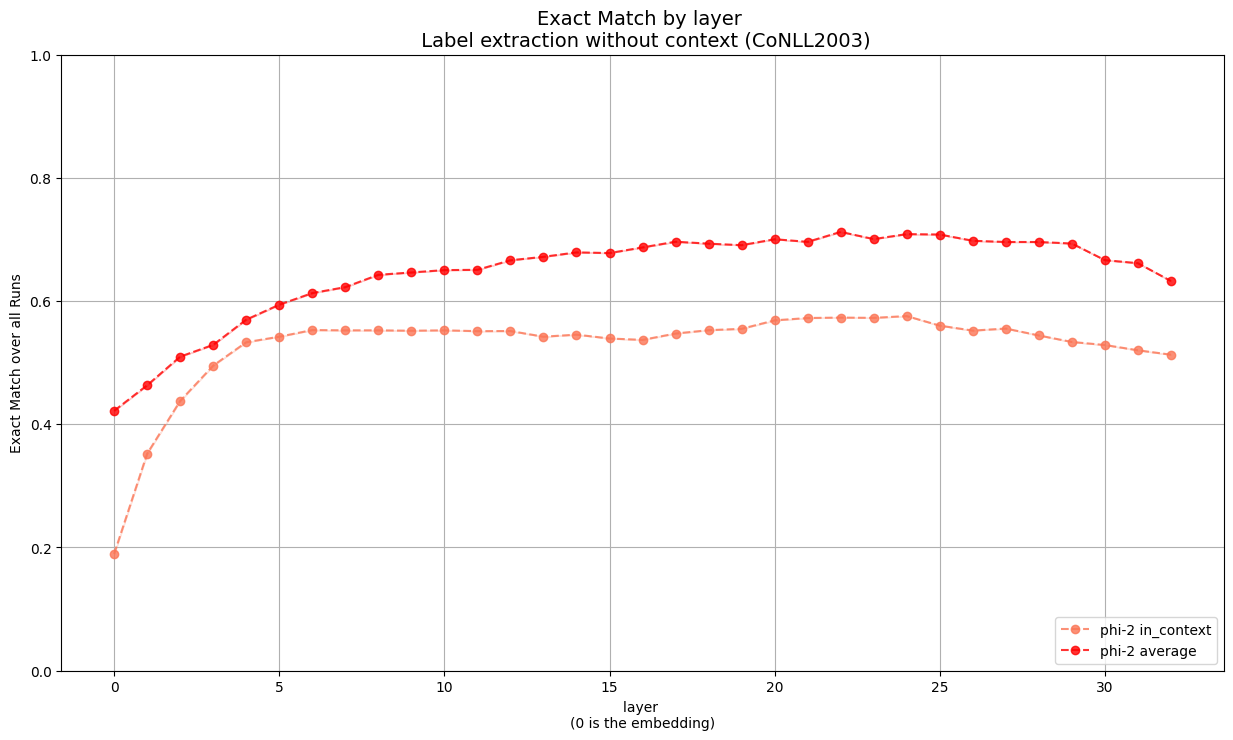

In [26]:
methods = [
    "in_context",
    "average",
]
normalize_layers = False
plot_aggregated_methods(new_results,
                        model_name, 
                        metric, 
                        dataset=dataset, 
                        with_context = with_context, 
                        methods=methods, 
                        normalize_layers=normalize_layers, 
                        min_y=0, max_y=max_y)
tikzplotlib.save(f"./plots/BaselineAvgComp_{dataset}_{model_name.split('/')[-1]}_with{' ' if with_context else 'out'}_ctx_tokens.tex")
plt.show()

# Dissecting Inference Data

## Load inference results from a job

In [68]:
# Parameters
layer = 22
model_name = "gpt2-large"
model_name = "gpt2-xl"
model_name = "gpt2-medium"
model_name = "mistral-7B"
model_name = "EleutherAI/pythia-6.9b"
model_name = "EleutherAI/pythia-160m"
model_name = "phi-1_5"
model_name = "EleutherAI/pythia-1b"
model_name = "EleutherAI/pythia-1.4b"
model_name = "EleutherAI/pythia-410m"
model_name = "phi-3"
model_name = "EleutherAI/pythia-2.8b"
model_name = "phi-2"

with_context = False
with_context = True

dataset_name = "WebNLG"
dataset_name = "TACRED"
dataset_name = "CoNLL2003"


### Inspect inference

In [74]:
hf_name = loading.get_official_model_name(model_name)
tokenizer = AutoTokenizer.from_pretrained(hf_name)
extraction_method = "in_context"
extraction_method = "random_sample"

### Load inference file
inference = get_inference_res(results, 
                              model_name, 
                              layer, dataset_name, 
                              with_context,
                              extraction_method= extraction_method,
                              verbose=True)

#print some fail examples
print("Ex of Failed examples:\n")
print("Original:".center(40) + " | " + "Inferred:".center(40)+ '\n'+"-"*84)
limit = 20
fails = set()
for item in inference:
    if len(fails) >= limit: break
    item = inference[np.random.randint(len(inference))]
    if item['entity'] == item['generation'] or item['generation'] in fails: continue
    fails |= {item['generation']}
    print(f"{item['entity'].center(40)} | {item['generation'].center(40)}")

found 1 results for layer 22 of phi-2 with context on CoNLL2003
got inference files: /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/4a759e3afb536d96e451342c0f89d3913cab4077f9ab0173ec5010eb567e402f/Inference_phi-2_l22.json
Ex of Failed examples:

               Original:                 |                Inferred:                
------------------------------------------------------------------------------------
             to order Swiss              | The conservative Radical Democrats (FDP) have said
                 k 312-                  |          (Chicago newsdesk 312-         
                  U.S                    |                  (U.S.)                 
              outdistanced               |               outdistanced              
              India said on              |       the Rubber Board of India on      
             CHRISTMAS MARK              |        LUXEMBOURG CHRISTMAS MARK        
             and appealed to             |   

In [55]:
item

{'entity': ' rising to head', 'generation': 'to head'}

In [80]:
entities = [it["entity"] for it in inference]

ent, counts = np.unique(entities, return_counts=True)
m = 10
#print the most frequent entities
print(f"Number of unique entities: {len(ent)}\n")
print("Most frequent entities:")
for e, c in zip(ent[np.argsort(-counts)][:m], -np.sort(-counts)[:m]):
    print(f"{e} : {c}")

Number of unique entities: 4352

Most frequent entities:
 (Germany) : 11
ONDON 1996- : 10
LONDON 1996 : 8
.S. : 8
 (U. : 8
U.S : 7
 (France) : 6
NEW YORK 1996 : 6
 said on Friday : 5
.N. : 5


In [23]:
import evaluate # c42cd74c33308233ff4a59e76e8c0ed3f568bd7b3f1c182a36f45748c0b6d846
prediction = [ item['generation'] for item in inference]
reference = [ [item['entity']] for item in inference]
chrf = evaluate.load("chrf")
evaluation = chrf.compute(predictions=prediction, references=reference)
print(evaluation)

# optional implem, maybe cleaner ??
# torchmetrics.functional.text.chrf_score(prediction, reference)


Using the latest cached version of the module from /home/morand/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--chrf/d244bab9383988714085a8dacc4871986d9f025398581c33d6b2ee22836b4069 (last modified on Thu Jun 27 14:17:21 2024) since it couldn't be found locally at evaluate-metric--chrf, or remotely on the Hugging Face Hub.


{'score': 60.943550192620165, 'char_order': 6, 'word_order': 0, 'beta': 2}


### Labels distribution

In [81]:

def augment_with_label_length(dataset):
    # count the number of tokens in the labels
    labels = {}
    for item in dataset:
        if item['entity'] not in labels:
            labels[item['entity']] = tokenizer(item['entity'], return_tensors="pt")["input_ids"].shape[1]

    # augment dataset set with label lenght 
    for item in dataset:
        item['label_length'] = labels[item['entity']]

augment_with_label_length(inference)
#print some examples
for i in range(15):
    item = inference[np.random.randint(len(inference))]
    tokens = tokenizer(item['entity'])["input_ids"]
    str_tokens = tokenizer.convert_ids_to_tokens(tokens)
    print(f"Entity tokens : {str_tokens } | Label length: {item['label_length']} | Generation: {item['generation']} ")

Entity tokens : ['ĠAviv', 'Ġ1', 'ĠBet'] | Label length: 3 | Generation: el 1 Bet 
Entity tokens : ['Ġexplodes', 'Ġoutside', 'Ġhome'] | Label length: 3 | Generation: outside home 
Entity tokens : ['Ġeastern', 'Ġcity', 'Ġof'] | Label length: 3 | Generation: the eastern city of 
Entity tokens : ['TA', 'Ġ10', 'Ġ8'] | Label length: 3 | Generation: ATLANTA 10 8 
Entity tokens : ['ĠShim', 'azaki', 'ĠKy'] | Label length: 3 | Generation: Shimazaki Ky 
Entity tokens : ['Ġ(', 'China', ')'] | Label length: 3 | Generation: (China) 
Entity tokens : ['10', '.', 'ĠAnita'] | Label length: 3 | Generation: 10. Anita 
Entity tokens : ['ana', 'ĠM', 'itter'] | Label length: 3 | Generation: Tatjana Mitter 
Entity tokens : ['LAND', 'Ġ6', 'Ġ7'] | Label length: 3 | Generation: AK 6 7 
Entity tokens : ['Ġthe', 'Ġright', 'Ġby'] | Label length: 3 | Generation: by 
Entity tokens : ['Ġovers', 'Ġin', 'Ġthe'] | Label length: 3 | Generation: were all out in the 
Entity tokens : ['T', 'AM', 'PA'] | Label length: 3 | Gen

in Test set: 4842 labels with >1 tokens 4842 items (100.0%)


/tmp/ipykernel_2021587/1296757397.py:29: UserWarning:

FixedFormatter should only be used together with FixedLocator



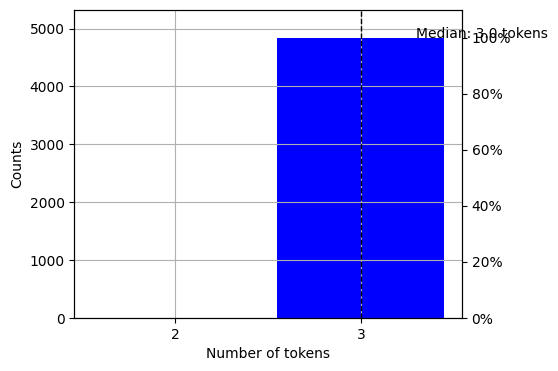

In [82]:
#plot the distribution of labels length
m = 10
#plot the distribution of labels length, with shifted x axis
lengths = [it["label_length"] for it in inference]
labels_len, counts = np.unique(lengths, return_counts=True)
total = len(lengths)
percentage = [c/total*100 for c in counts]
max_val = max(counts)
max_percent = max(percentage)
max_y_ratio = 1.1

# print(f"Test set: {len(lengths)} items for {len(labels)} unique labels")
#compute count of labels with more than 1 tokens
mutli_tokens_counts = np.sum([c for l, c in zip(labels_len, counts) if l > 1])
print(f"in Test set: {mutli_tokens_counts} labels with >1 tokens {len(lengths)} items ({mutli_tokens_counts/len(lengths)*100:.1f}%)")

# Plot the distribution of label lengths
fig, ax1 = plt.subplots(figsize=(5, 4))
ax1.bar(labels_len, counts, width=0.9, align='center', label='Counts', color='b')
ax1.set_ylim(0, max_val * max_y_ratio)
ax1.set_ylabel("Counts")
ax1.set_xlabel("Number of tokens")
ax1.grid()
# Create a second y-axis for the percentage (right)
ax2 = ax1.twinx()
ax2.plot(labels_len, percentage, color='r', marker='o', linestyle='--',alpha=0.0, label='Percentage')
ax2.set_ylim(0, max_percent * max_y_ratio)
#add % to the right y ticks 
ax2.set_yticklabels([f"{int(t)}%" for t in ax2.get_yticks()])
#same y axis for both plots
# Set x-axis ticks to be every integer (1 token, 2 tokens, etc.)
ax1.set_xticks(np.arange(min(labels_len), max(labels_len) + 1, 1.0))
# Calculate the mean and median of the label lengths
mean = np.mean(lengths)
median = np.median(lengths)
# Add a vertical line for the median
ax1.axvline(median, color='k', linestyle='dashed', linewidth=1)
ax1.text(median + 0.3, np.max(counts), f"Median: {median:.1f} tokens", color='k')
# Set the title, customizing it with dataset_name and model_name
# plt.title(f"Distribution of labels length in {dataset_name}\n" f"with {model_name.split('/')[-1]} tokenization")
#add grid 
tikzplotlib.save(f"./plots/EntityLengths_{dataset_name}_{model_name.split('/')[-1]}.tex")
plt.show()

### Progression of Performance through layers

In [83]:
hf_name = loading.get_official_model_name(model_name)
tokenizer = AutoTokenizer.from_pretrained(hf_name)


layers = [-1, 5, 15, 23]

### Load inference file
inferences = [
    get_inference_res(results, model_name, layer, dataset_name, with_context, verbose=True)
    for layer in layers]
samples = [[]*len(layers)]

N = 5 # number of examples to display per step 
width = 25
columns = [f"Inferred Layer {l+1}" for l in layers]

#create dataframe
df = []
#fill it by joining all inferences
for i in range(len(inferences[0])):
    ent = inferences[0][i]["entity"]
    row = {"entity": ent}
    score = 0
    for layer, key, inference in zip(layers, columns, inferences):
        gen = inference[i]["generation"]
        row[key] = gen
        if gen == ent: score += 1
    row["score"] = score
    #add row to dataframe
    df.append(row)
df = pd.DataFrame(df)
#print some fail examples
# print("Ex of Failed examples:\n")
# print N examples for each possible score
print("|".join(["Entity".center(width)] + [f"Layer {l+1}".center(width) for l in layers]))
for s in range(len(layers) + 1):
    print(f" Score {s}: ".center((1+width)*(len(layers)+1), "-"))
    for i in range(N):
        print(f"{df[df['score'] == s].iloc[i]['entity'].center(width)}", end="|")
        for layer in layers:
            print(f"{df[df['score'] == s].iloc[i][f'Inferred Layer {layer+1}'].center(width)}", end="|")
        print()

found 6 results for layer -1 of phi-2 with context on CoNLL2003
got inference files: /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/3393169f8114b47ff3e41d26fd37d3dee2cedd1138f7a69ff29a69a6b9f07e70/Inference_phi-2_l-1.json
found 6 results for layer 5 of phi-2 with context on CoNLL2003
got inference files: /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/1f74c3e0a6268acbaed19ed748be145c4b66d112fbb249da27f55a5d44395741/Inference_phi-2_l5.json
found 6 results for layer 15 of phi-2 with context on CoNLL2003
got inference files: /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/3649362086f69745106f4e810c7f6a2d77d88d094c26d29c5767b2156dce761d/Cleaned_Inference_phi-2_l15.json
found 6 results for layer 23 of phi-2 with context on CoNLL2003
got inference files: /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/30ba64798ba81866f2ed979dd94f6e7370e83bfe2eab4309618c31d48c8d966d/Inference_phi-2_l23.json
  

In [84]:
print([len(inf) for inf in inferences])
#print inferences from diff inferences
for i in range(5):
    ind = np.random.randint(len(inferences[0]))
    for inf in inferences:
        print(f"Entity: {inf[ind]['entity']}")
        print(f"Generation: {inf[ind]['generation']}")
        print(f"Tokens: {tokenizer(inf[ind]['generation'])['input_ids']}")
        print("\n")

[5389, 5389, 5389, 5389]
Entity: Newmont
Generation: Newmont
Tokens: [3791, 8691]


Entity: Newmont
Generation: Newmont
Tokens: [3791, 8691]


Entity: Newmont
Generation: Newmont
Tokens: [3791, 8691]


Entity: Newmont
Generation: Newmont
Tokens: [3791, 8691]


Entity: HAVELANGE
Generation: WEAHANGE
Tokens: [8845, 18429, 27746]


Entity: HAVELANGE
Generation: SOCCER
Tokens: [15821, 4093, 1137]


Entity: HAVELANGE
Generation: HAVEL
Tokens: [7801, 18697]


Entity: HAVELANGE
Generation: HAVELANGE
Tokens: [7801, 18697, 27746]


Entity: United Nations
Generation: United Nations
Tokens: [17013, 7973]


Entity: United Nations
Generation: United Nations
Tokens: [17013, 7973]


Entity: United Nations
Generation: United Nations
Tokens: [17013, 7973]


Entity: United Nations
Generation: United Nations
Tokens: [17013, 7973]


Entity: Russian
Generation: Russian
Tokens: [16220]


Entity: Russian
Generation: Russian
Tokens: [16220]


Entity: Russian
Generation: Russian
Tokens: [16220]


Entity: Russi

# Advanced Plots

In [28]:
#parameters
model_names = [
    # "gpt2-small",
    # "gpt2-medium",
    # "gpt2-large",
    # "gpt2-xl",
    # "mistral-7B",
    "phi-2",
    "phi-1_5",
    "phi-3",
    # "EleutherAI/pythia-160m",
    # "EleutherAI/pythia-410m",
    # "EleutherAI/pythia-1b",
    # "EleutherAI/pythia-2.8b",
    # "EleutherAI/pythia-6.9b",
    # "EleutherAI/pythia-1.4b",
]
with_context = 0
with_context = 1

dataset_name = "TACRED"
dataset_name = "WebNLG"
dataset_name = "CoNLL2003"

### Plot Perf according to label length

Using the latest cached version of the module from /home/morand/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--chrf/d244bab9383988714085a8dacc4871986d9f025398581c33d6b2ee22836b4069 (last modified on Thu Jun 27 14:17:21 2024) since it couldn't be found locally at evaluate-metric--chrf, or remotely on the Hugging Face Hub.


Best layer for phi-2: 21, exact match: 61.277, extraction method: in_context
found 6 results for layer 21 of phi-2 without context on CoNLL2003
got inference files: /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/35b7d60517c8977587ddcda71351074524667bafd15f1464d2a872f72abd9a5d/Inference_phi-2_l21.json


Using the latest cached version of the module from /home/morand/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--chrf/d244bab9383988714085a8dacc4871986d9f025398581c33d6b2ee22836b4069 (last modified on Thu Jun 27 14:17:21 2024) since it couldn't be found locally at evaluate-metric--chrf, or remotely on the Hugging Face Hub.


Best layer for phi-1_5: 14, exact match: 49.119, extraction method: in_context
found 1 results for layer 14 of phi-1_5 without context on CoNLL2003
got inference files: /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/8b9ee8fc623431f992a5e0c1e4bfe13576f4d8d01a48da922d4e837ffaaa4481/Inference_phi-1_5_l14.json


Using the latest cached version of the module from /home/morand/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--chrf/d244bab9383988714085a8dacc4871986d9f025398581c33d6b2ee22836b4069 (last modified on Thu Jun 27 14:17:21 2024) since it couldn't be found locally at evaluate-metric--chrf, or remotely on the Hugging Face Hub.


Best layer for phi-3: 20, exact match: 62.283, extraction method: in_context
found 1 results for layer 20 of phi-3 without context on CoNLL2003
got inference files: /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/4699b48b2a78ae4658310ee1de855960c60cf56bd32483d9663005ad4bbd0bd2/Inference_phi-3_l20.json


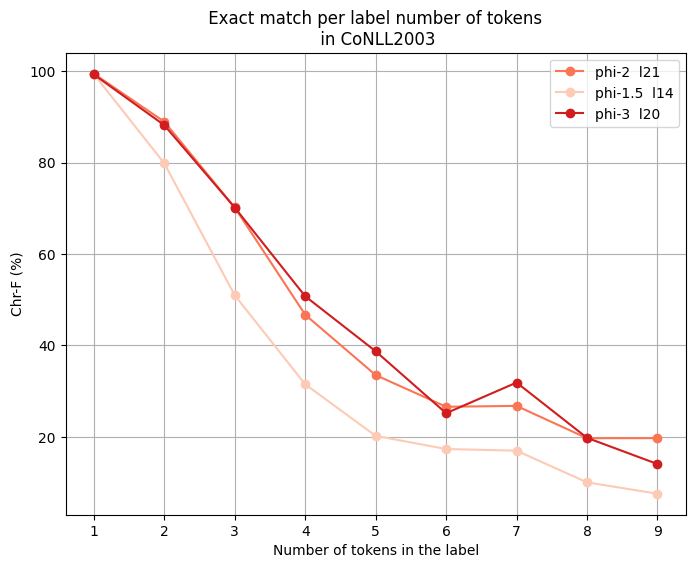

In [49]:
#compute accuracy per quantile
# divide counts per quantiles of counts
def Perf_by_N_tokens(
                    model_names, 
                    metric:str = "Exact Match",
                    method:str = "in_context",
                    verbose:bool = False,
                    min_labels_numb:int = 5):
    
    plt.figure(figsize=(8, 6))
    #compute accuracy per quantile for each model
    for model_name in model_names:
        #get best layer for this model
        results["metric"] = results["Eval"].apply(lambda x: x[metric])
        filtered = results[(results["model_name"] == model_name) 
                            & (results["dataset_name"] == dataset_name)
                            & (results["with_context"] == with_context)
                            & (results["extraction_method"] == method)
                           ]
        if len(filtered) == 0:
            print(f"No results for {model_name}")
            continue
        
        idx = filtered["metric"].idxmax()
        layer = filtered.loc[idx]["layer"]
        print(f"Best layer for {model_name}: {layer}, exact match: {filtered.loc[idx]['metric']:.3f}, extraction method: {filtered.loc[idx]['extraction_method']}")
        inference = get_inference_res(results, 
                                      model_name, 
                                      layer, 
                                      dataset_name, 
                                      with_context, 
                                      extraction_method=method,
                                      verbose=verbose)
        
        #count number of tokens in each label
        augment_with_label_length(inference)
        
        chrf = evaluate.load("chrf")
        N_toks = set([item["label_length"] for item in inference])
        # print(f"Number of unique label lengths: {N_toks}")
        N_tok_accs = {}
        prev = 0

        for N_tok in sorted(N_toks):
            
            #get entities in this quantile
            entity_inferences = [item for item in inference if item["label_length"] == N_tok]
            # print(f"data items with {N_tok} tokens entity label: {len(entity_inferences)}")
            if len(entity_inferences) < min_labels_numb:
                continue
            #compute accuracy
            if metric == "Exact Match":
                # in percent
                res = 100 * sum([item["entity"] == item["generation"] for item in entity_inferences])/len(entity_inferences)

            elif metric == "Chr-F":
                res = chrf.compute(predictions=[ item['generation'] for item in entity_inferences], 
                                          references=[ [item['entity']] for item in entity_inferences]
                                          )["score"]
            else:
                raise ValueError(f"Unknown metric: {metric}")
            
            N_tok_accs[N_tok] = res #in percent

        # plot of accuracy per quantile
        plt.plot(list(N_tok_accs.keys()), 
                 list(N_tok_accs.values()), 
                'o-', 
                label=model_name.split("/")[-1].replace('_','.') + f"  l{layer}", 
                color=model_colors[model_name])
        # break
    
    plt.xlabel("Number of tokens in the label")
    plt.ylabel(f"{metric} (%)")
    plt.grid()
    plt.legend()
    plt.title(f" Exact match per label number of tokens \n in {dataset_name}")

method = "average"
method = "random_sample"
method = "in_context"
metric = "Exact Match"
metric = "Chr-F"

Perf_by_N_tokens(model_names, 
                 metric=metric, 
                 method=method,
                 verbose=True)
tikzplotlib.save(f"./plots/PerfByNTokens_{dataset_name}_{'with' if with_context else 'no'}_context.tex")
plt.show()

### Plot success rate as a function of the entity appearance in the Pile

In [30]:
counts_file = f"/home/morand/code/entityrepresentations/datasets/counts_{dataset_name}_TestEntities.json"
print(f"loading {counts_file}...")
with open(counts_file) as json_file:
    counts = json.load(json_file)

entity = "CALGARY"
entity = "McDonald's"
print(f"Entity {entity} appears {counts[entity]} times in the Pile")

loading /home/morand/code/entityrepresentations/datasets/counts_CoNLL2003_TestEntities.json...
Entity McDonald's appears 359411 times in the Pile


In [88]:
#compute accuracy per quantile
# divide counts per quantiles of counts
def Perf_by_quantiles(model_names, 
                    n_quantiles:int = 10,
                    metric:str = "Exact Match",
                    method:str = "in_context",
                    verbose:bool = False):
    #compute quantiles for given counts (specific to one dataset)
    global counts
    counts_s = pd.Series(counts) # make sure to load the right counts_s file
    quantiles = counts_s.quantile(np.linspace(0, 1, n_quantiles+1))
    quantiles = quantiles.to_dict()
    #check number of tokens in each quantile
    prev = 0
    if verbose: 
        print("computed quantiles:")
        for q, q_val in quantiles.items():
            if q == 0: continue
            print(f" {str(int(prev)).center(10)} < counts_s < {str(int(q_val)).center(10)} : {sum((prev < counts_s) & (counts_s < q_val))} entities")
            prev = q_val
    
    plt.figure(figsize=(8, 6))
    #compute accuracy per quantile for each model
    for model_name in model_names:
        #get best layer for this model
        results["metric"] = results["Eval"].apply(lambda x: x[metric])
        filtered = results[(results["model_name"] == model_name) 
                           & (results["dataset_name"] == dataset_name)
                           & (results["with_context"] == with_context)
                            # & (results["extraction_method"] == method)
                           ]
        if len(filtered) == 0:
            print(f"No results for {model_name}")
            continue
        
        idx = filtered["metric"].idxmax()
        layer = filtered.loc[idx]["layer"]
        print(f"Best layer for {model_name}: {layer}, exact match: {filtered.loc[idx]['metric']:.3f}, extraction method: {filtered.loc[idx]['extraction_method']}")
        inference = get_inference_res(results, model_name, layer, dataset_name, with_context, verbose=verbose)
        quantile_accs = {}
        prev = 0
        for q, q_val in quantiles.items():
            if q == 0: continue
            #get entities in this quantile
            entities = counts_s[(prev < counts_s) & (counts_s < q_val)].index
            #get all inferences for these entities
            entity_inferences = [item for item in inference if item["entity"] in entities]
            if verbose: print(f"entities in quantile {q:.1f}: appear {len(entity_inferences)} in test set")
            #compute accuracy
            acc = sum([item["entity"] == item["generation"] for item in entity_inferences])/len(entity_inferences)
            quantile_accs[q] = 100*acc #in percent

        # plot of accuracy per quantile
        plt.plot([0] + list(quantile_accs.keys()), 
                [0] + list(quantile_accs.values()), 
                'o-', 
                label=model_name.split("/")[-1].replace('_','.') + f"  l{layer}", 
                color=model_colors[model_name])
    
    plt.xlabel("Quantile")
    plt.ylabel(f"{metric} (%)")
    plt.grid()
    plt.legend()
    plt.title(f" {metric} per quantile of entities counts in the Pile \n in {dataset_name}")

In [89]:
Perf_by_quantiles(model_names, verbose=True, 
                  metric=metric, 
                  method='in_context')
tikzplotlib.save(f"plots/quantiles_{'with' if with_context else 'no'}_context.tex")
plt.show()

computed quantiles:
     0      < counts_s <    485     : 1 entities
    485     < counts_s <    969     : 0 entities
    969     < counts_s <    1453    : 0 entities
    1453    < counts_s <    1937    : 0 entities
    1937    < counts_s <    2421    : 0 entities
    2421    < counts_s <    2905    : 0 entities
    2905    < counts_s <    3389    : 0 entities
    3389    < counts_s <    3873    : 0 entities
    3873    < counts_s <    4357    : 0 entities
    4357    < counts_s <    4841    : 0 entities
Best layer for phi-2: 24, exact match: 0.958, extraction method: average
found 6 results for layer 24 of phi-2 with context on CoNLL2003
got inference files: /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/18da91b6e5e906663929982477fb91bce8fc233f3b5d468c15e570a7bf4c13ca/Inference_phi-2_l24.json
entities in quantile 0.1: appear 0 in test set


ZeroDivisionError: division by zero

<Figure size 800x600 with 0 Axes>

### Correlation between label length and frequency

In [90]:
## add "counts" to the results
for it in inference:
    it["counts"] = counts[it["entity"]]
augment_with_label_length(inference)

#plot the relation between counts and lentgh
plt.figure(figsize=(10, 8))
plt.plot([it["label_length"] for it in inference], 
         [it["counts"] for it in inference], 'o')
plt.xlabel("Number of tokens in the label")
plt.ylabel("Counts in the Pile")
#log 
plt.yscale('log')
plt.grid()
plt.title(f"Label length vs counts in the Pile \n in {dataset_name}")
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

## 3D Plot of counts, label length and accuracy 

Best layer for phi-1_5: 13, exact match: 0.511, extraction method: in_context
Best layer for phi-2: 21, exact match: 0.649, extraction method: in_context
Best layer for phi-3: 20, exact match: 0.665, extraction method: in_context


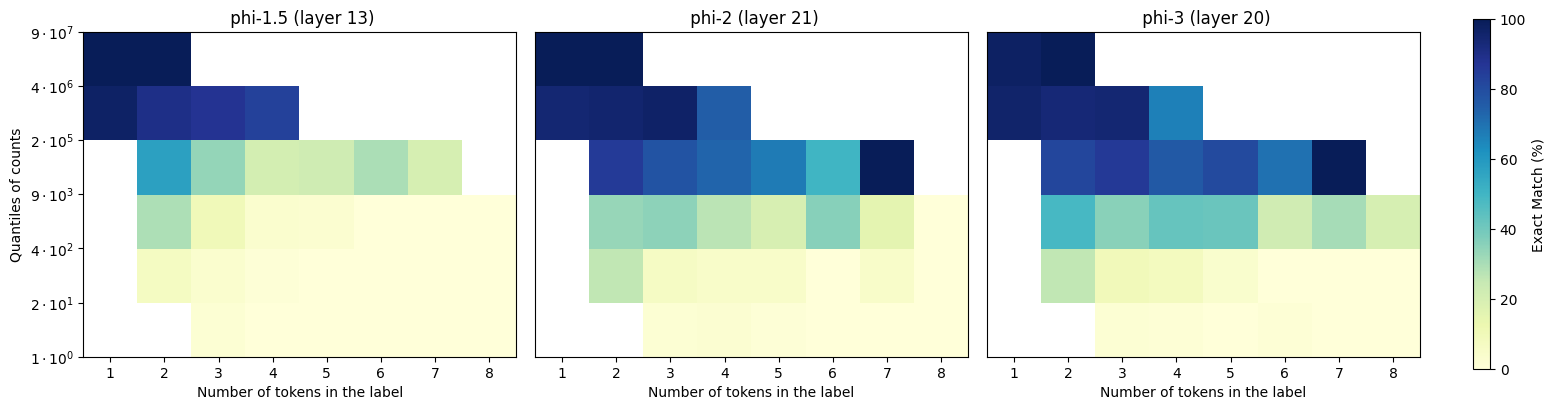

In [34]:
# compute accuracy per quantile
# divide counts per quantiles of counts
def Perf_by_N_tokens_Freq(
                    model_names, 
                    metric:str = "Exact Match",
                    method:str = "in_context",
                    verbose:bool = False,
                    max_N_tokens:int = 10,
                    with_context:bool = False,
                    min_labels_numb:int = 5):
    
# discretize the counts in log scale
    counts_s = pd.Series(counts)
    min_c, max_c = counts_s.min(), counts_s.max()
    n_quantiles = 7
    quantiles = np.logspace(0, np.log10(max_c), n_quantiles)
    
    accs = np.zeros((n_quantiles-1, max_N_tokens))

    max_per_row = 3
    n_rows = len(model_names)//max_per_row
    n_cols = min(len(model_names), max_per_row)

    #subplots for each model
    fig, axes = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(15, 5*n_rows))

    #flattern axes
    axes = axes.flatten()
    #compute accuracy per quantile for each model
    for i, model_name in enumerate(model_names):
        #get best layer for this model
        results["metric"] = results["Eval"].apply(lambda x: x[metric])
        filtered = results[(results["model_name"] == model_name) 
                            & (results["dataset_name"] == dataset_name)
                            & (results["with_context"] == with_context)
                            & (results["extraction_method"] == method)
                           ]
        if len(filtered) == 0:
            print(f"No results for {model_name}, {dataset_name}, {with_context}, {method}")
            continue
        
        idx = filtered["metric"].idxmax()
        layer = filtered.loc[idx]["layer"]
        print(f"Best layer for {model_name}: {layer}, exact match: {filtered.loc[idx]['metric']:.3f}, extraction method: {filtered.loc[idx]['extraction_method']}")
        
        inference = get_inference_res(results, model_name, layer, dataset_name, with_context, verbose=verbose)
        
        #count number of tokens in each label
        augment_with_label_length(inference)
        #augment with counts
        for it in inference:
            it["counts"] = counts[it["entity"]]
        
        N_toks = set([item["label_length"] for item in inference if item["label_length"] <= max_N_tokens])
        # print(f"Number of unique label lengths: {N_toks}")

        for N_tok in sorted(N_toks):
            # print(f"Number of tokens: {N_tok}")
            #get entities in this quantile
            Ntoks_entity_inferences = [item for item in inference if item["label_length"] == N_tok]
            # print(f"data items with {N_tok} tokens entity label: {len(Ntoks_entity_inferences)}")
            # print(Ntoks_entity_inferences[:10])
            # print(f"data items with {N_tok} tokens entity label: {len(Ntoks_entity_inferences)}")
            if len(Ntoks_entity_inferences) < min_labels_numb:
                continue
            prev = 0
            for q, quantile in enumerate(quantiles[1:]):
                #get entities in this quantile
                #get all inferences for these entities
                Ntoks_counts_entity_inferences = [item for item in Ntoks_entity_inferences 
                                     if (item["counts"] >= prev) and (item["counts"] < quantile)]
                #filter duplicated entities
                Ntoks_counts_entity_inferences = list({item["entity"]: item for item in Ntoks_counts_entity_inferences}.values())
                # print(f"entities in quantile {prev:.1e}-{quantile:.1e} in test set {len(Ntoks_counts_entity_inferences)}")
                
                if len(Ntoks_counts_entity_inferences) >= min_labels_numb:
                    #compute accuracy
                    acc = sum([item["entity"] == item["generation"] for item in Ntoks_counts_entity_inferences])/len(Ntoks_counts_entity_inferences)
                    accs[q, N_tok-1] = 100*acc #in percent
                else:
                    accs[q, N_tok-1] = np.nan
                prev = quantile

        # plot of accuracy per quantile
        img = axes[i].imshow(accs, cmap=plt.cm.YlGnBu, interpolation='nearest', vmin=0, vmax=100)
        #invert y axis
        axes[i].invert_yaxis()
        axes[i].set_yticks([])
        axes[i].set_xticks(np.arange(1,max_N_tokens+1)-1, [str(i) for i in range(1, max_N_tokens+1)])
        axes[i].set_xlabel("Number of tokens in the label")
        axes[i].set_title(f" {model_name.split('/')[-1].replace('_','.') } (layer {layer})")
    
    # reverse y axis
    #shift x axis to 1
    # plt.xticks(np.arange(1, max_N_tokens, 1))
    def scientific_formatter(x):
        a, b = '{:.0e}'.format(x).split('e')
        b = int(b)
        a = a.rstrip('0').rstrip('.')
        return r'${} \cdot 10^{{{}}}$'.format(a, b)
    y_labels = [scientific_formatter(quantile) for quantile in quantiles[:]]

    for i in range(0, n_cols * n_rows, n_cols):
        axes[i].set_yticks(np.arange(n_quantiles)-0.5, y_labels)
        axes[i].set_ylabel("Quantiles of counts")
        #shift x ticks
    #add colorbar 
    plt.tight_layout()
    cbar_ax = fig.add_axes([0.9, 0.15, 0.1, 0.7])	
    cbar_ax.axis('off')         #make the ax invisible
    plt.colorbar(img, ax=cbar_ax, label="Exact Match (%)")
    fig.subplots_adjust(right=0.95)
    # fig.suptitle(f"EM vs #tokens and Frequency in {dataset_name} entities", fontsize=16)

family = "pythia"
family = "phi"
with_context = True
with_context = False

Perf_by_N_tokens_Freq(
    families[family], 
    metric="Exact Match", 
    with_context=with_context,
    max_N_tokens=8,
    # verbose=True, 
    )
# tikzplotlib.save(f"./plots/PerfByNTokens_{dataset_name}_{'with' if with_context else 'no'}_context.tex")
plt.savefig(f"./plots/PerfByNTokens_{family}_{'with' if with_context else 'no'}_context.svg")
plt.show()

# Exploring Learned TaskVecs 

In [35]:
model_name = "phi-2"
method = "in_context"
dataset_name = "CoNLL2003"

with_context = True
with_context = False

## TaskVecs Similarities

/tmp/ipykernel_2021587/2803411021.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  taskvec = torch.load(taskvec_path)


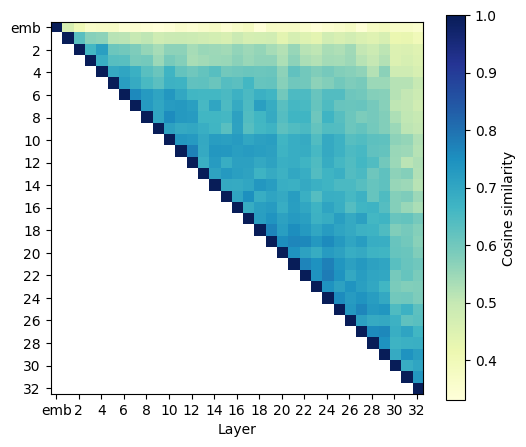

/tmp/ipykernel_2021587/2803411021.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  taskvec = torch.load(taskvec_path)


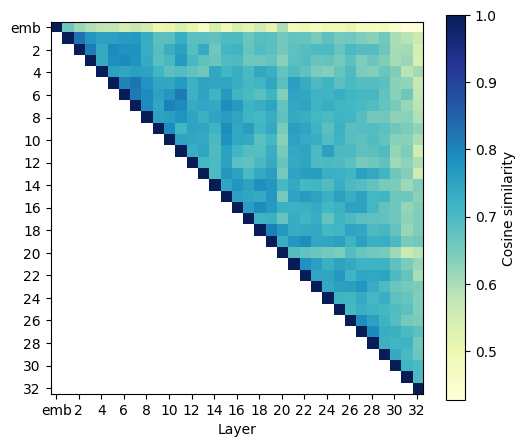

In [36]:
import numpy as np
import torch

@torch.no_grad()
def plot_tv_sims(
                results,
                model_name:str,
                dataset_name:str,
                with_context:bool,
                method:str,
    ):
    
    filtered_results = results[(results["model_name"] == model_name)
                                & (results["dataset_name"] == dataset_name)
                                & (results["with_context"] == with_context)
                                & (results["extraction_method"] == method)
                            ]

    filtered_results.sort_values(by="layer", ascending=False).head(10)
    layers = np.unique(filtered_results["layer"].to_list())

    taskVecs= {}

    for ind, data in filtered_results.iterrows():
        EM = data["Eval"]["Exact Match"]

        taskvec_path = get_taskVec(
                filtered_results,
                model_name,
                layer=data["layer"],
                dataset_name=dataset_name,
                with_context=with_context,
                verbose=False
                )
        if data["layer"] not in taskVecs or taskVecs[data["layer"]]["Exact Match"] < EM:
            taskvec = torch.load(taskvec_path)
            taskVecs[data["layer"]] = { 
                "taskVec": taskvec,
                "Exact Match": EM,
                "model_name": model_name,
                "layer": data["layer"],
                "dataset_name": dataset_name,
                "with_context": with_context,
                "extraction_method": method,
            }

    #compute similarity matrix
    sims = torch.zeros((len(layers), len(layers)))
    for i, l1 in enumerate(layers):
        for j, l2 in enumerate(layers):
            # print(f"Computing similarity between layer {l1} and layer {l2}")
            if l1 == l2:
                sims[i, j] = 1
            elif l1 < l2: 
                tv1 = taskVecs[l1]["taskVec"].view(-1)
                tv2 = taskVecs[l2]["taskVec"].view(-1)
                # print(f"tv1: {tv1.shape}, tv2: {tv2.shape}")
                sims[i, j] = torch.nn.functional.cosine_similarity(tv1, tv2, dim=0)
            else:
                sims[i, j] = torch.nan
        
    #plot the similarity matrix
    tick_every = 2
    plt.figure(figsize=(6, 5))
    # plt.title(f"Similarity between task vectors {model_name} {dataset_name} {'with' if with_context else 'without'} context")
    plt.imshow(sims, cmap=plt.cm.YlGnBu, interpolation='nearest')
    plt.colorbar(label="Cosine similarity")
    tick_layers = layers[::tick_every]
    x = [l+1 for l in tick_layers]
    labels = ["emb"] + [f"{l+1}" for l in tick_layers[1:]]
    plt.xticks(x, labels)
    plt.yticks(x, labels)
    plt.xlabel("Layer")
    

plot_tv_sims(results, model_name, dataset_name, with_context, method)
plt.savefig(f"./plots/TVSims_{model_name}_{dataset_name}_{'with' if with_context else 'no'}_context.pdf")
plt.show()
plot_tv_sims(results, model_name, dataset_name, not with_context, method)
plt.savefig(f"./plots/TVSims_{model_name}_{dataset_name}_{'with' if not with_context else 'no'}_context.pdf")


In [37]:
perfect_acc = 0
partial_acc = 0
for item in inference:
        # print(st(item).replace("', ", "'\n"))
        # prompts = item["prompt"]
        target = item["entity"].replace(" ", "")
        gen = item["generation"]
        gen_entity = gen.strip()
        # print("gen_entity:", gen)
        # print("target:", target)
        if gen_entity == target:
            perfect_acc += 1
        if gen_entity in target or target in gen_entity:
            partial_acc += 1

print({
        "Partial Match": partial_acc / len(inference),
        "Perfect Match Acc": perfect_acc / len(inference),
    })

{'Partial Match': 0.5767303766932641, 'Perfect Match Acc': 0.5412878084987939}
